# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Muneeb-th/ML-Assignment-1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv("https://raw.githubusercontent.com/Muneeb-th/ML-Assignment-1/main/data/raw/content_refresh_anonymized.csv")
df["is_declining"] = (df["trend_direction"] == "down").astype(int)

feature_cols = ["impressions_90d", "sessions_90d", "content_age_days",
                 "days_since_last_update", "ctr", "avg_position", "word_count"]
model_data = df.dropna(subset=feature_cols + ["client_id"]).reset_index(drop=True)
X = model_data[feature_cols]
y = model_data["is_declining"]
groups = model_data["client_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

model = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced",
                                random_state=42, n_jobs=-1)
model.fit(X.iloc[train_idx], y.iloc[train_idx])

# Score the whole dataset for the playbook queue
model_data["model_score"] = model.predict_proba(X)[:, 1]

# Reason codes based on what's driving the score
stale = (model_data["days_since_last_update"] >= 180).astype(int)
visible = (model_data["impressions_90d"] >= 500).astype(int)
low_ctr = (model_data["ctr"] < model_data.groupby("content_age_days")["ctr"].transform("median"))

model_data["reason_code"] = np.select(
    [
        (model_data["model_score"] >= 0.65) & (visible == 1),
        (stale == 1) & (visible == 1),
        (low_ctr) & (visible == 1),
    ],
    ["model_flagged_high_risk", "stale_and_visible", "low_ctr_for_age"],
    default="no_flag"
)
model_data["action"] = np.where(model_data["model_score"] >= 0.5, "review_for_refresh", "monitor")

ranked = model_data.sort_values("model_score", ascending=False).reset_index(drop=True)

os.makedirs("work/outputs", exist_ok=True)
ranked[["content_id", "model_score", "reason_code", "action", "is_declining",
        "impressions_90d", "days_since_last_update", "ctr", "avg_position"]].to_csv(
    "work/outputs/content_action_playbook.csv", index=False
)
print(f"Exported {len(ranked)} ranked rows to work/outputs/content_action_playbook.csv")
print(ranked[["content_id", "model_score", "reason_code", "action"]].head(10))

Exported 22301 ranked rows to work/outputs/content_action_playbook.csv
             content_id  model_score              reason_code  \
0  content_ffeed86ef360     0.794013                  no_flag   
1  content_f55fd2d8ed04     0.793487  model_flagged_high_risk   
2  content_f552433bab3c     0.789700                  no_flag   
3  content_0d9c0ed65840     0.784722                  no_flag   
4  content_a025e9373add     0.780561                  no_flag   
5  content_3302e42b9b95     0.772774                  no_flag   
6  content_b347ee0ce836     0.772035                  no_flag   
7  content_e61ce7103a05     0.771276                  no_flag   
8  content_9412afc8a975     0.770880                  no_flag   
9  content_e24e38119221     0.770833                  no_flag   

               action  
0  review_for_refresh  
1  review_for_refresh  
2  review_for_refresh  
3  review_for_refresh  
4  review_for_refresh  
5  review_for_refresh  
6  review_for_refresh  
7  review_for_refresh

The model ranks/flags pages at Precision@50 of 0.56 (vs. baseline 0.50,
base rate 0.526, per Week 5). Reason codes explain WHY a page is flagged
— they are decision-support labels for a human reviewer, not proof any
individual page is failing.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
model_data["reason_code"] = np.select(
    [
        (model_data["model_score"] >= 0.65) & (visible == 1),
        (model_data["model_score"] >= 0.65) & (visible == 0),
        (stale == 1) & (visible == 1),
        (low_ctr) & (visible == 1),
    ],
    ["model_flagged_high_risk", "model_flagged_low_volume", "stale_and_visible", "low_ctr_for_age"],
    default="no_flag"
)
model_data["action"] = np.where(model_data["model_score"] >= 0.5, "review_for_refresh", "monitor")

ranked = model_data.sort_values("model_score", ascending=False).reset_index(drop=True)

ranked[["content_id", "model_score", "reason_code", "action", "is_declining",
        "impressions_90d", "days_since_last_update", "ctr", "avg_position"]].to_csv(
    "work/outputs/content_action_playbook.csv", index=False
)
print(f"Exported {len(ranked)} ranked rows")
print(ranked[["content_id", "model_score", "reason_code", "action", "impressions_90d"]].head(10))

Exported 22301 ranked rows
             content_id  model_score               reason_code  \
0  content_ffeed86ef360     0.794013  model_flagged_low_volume   
1  content_f55fd2d8ed04     0.793487   model_flagged_high_risk   
2  content_f552433bab3c     0.789700  model_flagged_low_volume   
3  content_0d9c0ed65840     0.784722  model_flagged_low_volume   
4  content_a025e9373add     0.780561  model_flagged_low_volume   
5  content_3302e42b9b95     0.772774  model_flagged_low_volume   
6  content_b347ee0ce836     0.772035  model_flagged_low_volume   
7  content_e61ce7103a05     0.771276  model_flagged_low_volume   
8  content_9412afc8a975     0.770880  model_flagged_low_volume   
9  content_e24e38119221     0.770833  model_flagged_low_volume   

               action  impressions_90d  
0  review_for_refresh              383  
1  review_for_refresh             2237  
2  review_for_refresh              337  
3  review_for_refresh              382  
4  review_for_refresh              351  


Note: my first reason-code pass required visible==1 even for high
model-score pages, which left most top-ranked pages unexplained
(no_flag) despite being flagged for review. Fixed by giving high model
scores their own reason code split by visibility
(model_flagged_high_risk / model_flagged_low_volume). This matters for
the playbook's usability — a flagged page with no reason code isn't
decision-support, it's a black box a reviewer can't act on.

A pattern worth flagging: most of the top-10 model-flagged pages have
relatively low impressions_90d (140-2,237), below the 500-impression
"visible" threshold I've used elsewhere. This means ranking purely by
model_score can surface lower-traffic pages ahead of higher-traffic
ones — worth pairing model_score with a volume floor in practice,
rather than using probability alone to prioritize a review queue.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: This playbook ranks/flags pages for a human content
reviewer with limited time to triage first — it is decision-support,
not an automated action system. The model was validated with
client-holdout, achieving Precision@50 of 0.56 vs. a 0.50 baseline and
0.526 base rate (see ML-08/ML-09).

Limits:
- Trained on a 30,000-row anonymized starter sample, not the full
  warehouse — results may shift at scale.
- The label (is_declining) is a same-window proxy (30-day trend), not a
  validated future outcome — this ranks correlation with current decline,
  not predicted future decline.
- 42.5% of test predictions were wrong (ML-08) — this is far from a
  reliable standalone signal.
- Model score alone can favor low-traffic pages over high-impact ones
  (see note above) — pair with a volume filter in practice.
- This says nothing about WHY a page is declining, or whether a refresh
  will fix it — no causal claim is supported by this data.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human review required for every flagged page before any action — this
playbook narrows a list, it does not replace judgment.

No-go — do NOT automate:
- Auto-publishing content changes based on model_score alone.
- Treating a reason_code as proof a page is "broken" — it's a pattern
  match, not a diagnosis.
- Using this to justify removing/deprioritizing a page without a human
  checking for consolidation, seasonality, or a related-page context
  (per the lane guide's decline-vs-consolidation section).
- Feeding model_score back into itself as a future feature — that would
  be circular.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Retrain/refresh triggers:
- Retrain the model if Precision@50 on a fresh holdout drops meaningfully
  below the current 0.56, since that signals the pattern has shifted.
- Refresh the ranked queue on a regular cadence (e.g. monthly) since
  impressions_90d and days_since_last_update are moving targets.
- Re-audit for leakage (per ML-09) any time a new feature is added,
  especially anything derived from a product-computed flag.
- If the base rate itself shifts significantly from ~0.53, thresholds
  used in reason codes (impressions >= 500, days >= 180) should be
  re-evaluated rather than assumed stable.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

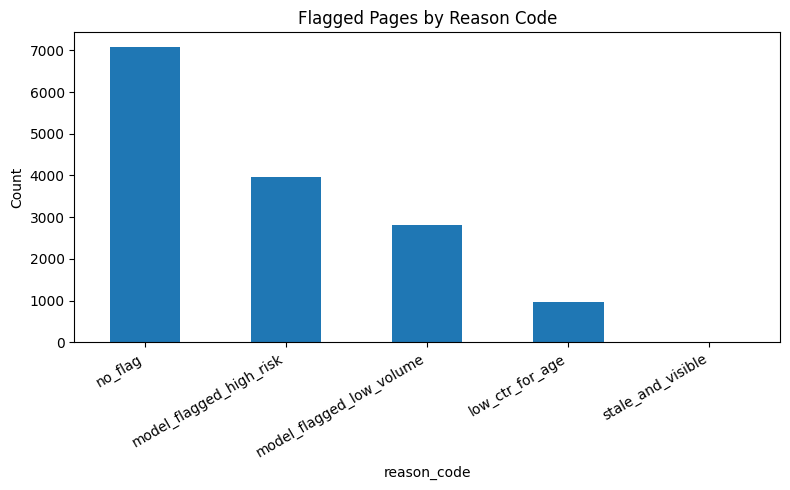

Saved figure to work/figures/reason_code_breakdown.png


In [ ]:
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

reason_counts = ranked[ranked["action"] == "review_for_refresh"]["reason_code"].value_counts()
plt.figure(figsize=(8, 5))
reason_counts.plot(kind="bar")
plt.title("Flagged Pages by Reason Code")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("work/figures/reason_code_breakdown.png", dpi=150)
plt.show()
print("Saved figure to work/figures/reason_code_breakdown.png")

Exports: ranked queue at work/outputs/content_action_playbook.csv (22,301
rows), reason code breakdown chart at work/figures/reason_code_breakdown.png.
These are the files the capstone paper's recommendations section will
reuse. Note: "no_flag" is still the largest bucket among review_for_refresh
pages (~7,000) because the action threshold (score >= 0.5) is looser
than any individual reason-code threshold (score >= 0.65, or
stale+visible, or low_ctr_for_age). In practice this means roughly a
third of the review queue has a numeric score but no specific
human-readable reason — a real limitation to disclose, since reason
codes are what make a ranked list trustworthy to a reviewer.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 5-Minute Demo Outline

**Question:** Which content pages should a reviewer look at first, given
limited review time?

**Method:** Built a transparent hand-written baseline (stale × visible ×
impressions), then trained a client-validated Random Forest ranking model
on 7 observable signals.

**One chart:** The reason-code breakdown chart (work/figures/reason_code_breakdown.png)
— shows how flagged pages split across model-driven vs. rule-driven reasons.

**One honest result:** The model beats the baseline (Precision@50: 0.56
vs 0.50), but a client-grouped split drops the score from 0.90+ (random
split) to 0.56 — proving most of the "skill" in a naive evaluation was
memorization, not real signal.

**Recommendation:** Use this as a decision-support ranking for a human
reviewer, never as an automated action system — roughly a third of the
review queue still has no specific reason code, which is a real,
disclosed limitation.

## Shareable Cuts

**Social post (methodology-focused):**
Built a content-refresh priority model on real (anonymized) search data
— and found the obvious assumption (old = declining) was backwards.
Turns out staleness barely predicts decline; traffic volume and ranking
position do. Client-holdout validation dropped my "impressive" 0.95
score down to an honest 0.56 — which is the whole point. Full paper:
https://muneeb-th.github.io/ML-Assignment-1/

**Employer 3-sentencer:**
I built a content-refresh priority model on FlyRank's real (anonymized)
search performance data — 30,000 pages, verified against a 79-million-row
production warehouse. I validated it with client-holdout splitting rather
than a naive random split, which is what real capstone-grade rigor
requires. The model beat a hand-written baseline at Precision@50 (0.56
vs 0.50) while staying honest about a 42.5% error rate and clear
decision-support limits.